"""
REVENUE INDEX NOTEBOOK
=======================
Computes daily production-weighted capture rate revenue index RI(t)
from simulated physical variables.

T_eff approach: NOCT hourly model (physics-based, no regression)
  - T_cell(h) = T_amb(h) + (NOCT-20)/800 · GHI(h)
  - T_eff_daily = GHI-weighted mean T_cell during daylight hours
  - uplift_doy  = mean(T_eff_daily - T_mean_24h) by day-of-year
  - T_eff_sim(t) = T_sim(t) + uplift_doy[doy(t)]

  Formulas:
  - T_eff(t)   = T_sim(t) + uplift_doy[doy(t)]
  - f_temp(t)  = 1 + γ · (T_eff(t) − T_STC)
  - P(t)       = (GHI_sim(t) / G_STC) · f_temp(t) · PR
  - RI(t)      = P(t) · CR_sim(t)
  - RI_annual  = Σ_{t∈year} RI(t)

In [1]:
# STEP 0 — Imports, paths, constants
# ─────────────────────────────────────────────────────────────────────────────
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import gaussian_kde
from pathlib import Path
import pickle
import warnings
import calendar
warnings.filterwarnings("ignore")

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
data_sim      = Path("../../Data/Simulated")
data_modelled = Path("../../Data/Modelled")
data_cleaned  = Path("../../Data/Cleaned")
data_results  = Path("../../Data/Results")
models_path   = Path("../../Code/Models")
data_results.mkdir(parents=True, exist_ok=True)

In [3]:
# ── physical constants ────────────────────────────────────────────────────────
G_STC  = 1000.0   # W/m²   — standard test condition irradiance
T_STC  = 25.0     # °C     — STC reference temperature
GAMMA  = -0.0043   # /°C    — temperature coefficient monocrystalline Si
PR     = 0.80     # —      — performance ratio
NOCT   = 45.0     # °C     — nominal operating cell temperature
 
print("── Step 0: Configuration ────────────────────────────────────────")
print(f"  G_STC  = {G_STC} W/m²")
print(f"  T_STC  = {T_STC}°C")
print(f"  γ      = {GAMMA} /°C")
print(f"  PR     = {PR}")
print(f"  NOCT   = {NOCT}°C  → heat coeff = {(NOCT-20)/800:.5f} °C·m²/W")
print(f"  data_sim     : {data_sim.resolve()}")
print(f"  data_results : {data_results.resolve()}")

── Step 0: Configuration ────────────────────────────────────────
  G_STC  = 1000.0 W/m²
  T_STC  = 25.0°C
  γ      = -0.0043 /°C
  PR     = 0.8
  NOCT   = 45.0°C  → heat coeff = 0.03125 °C·m²/W
  data_sim     : C:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\Data\Simulated
  data_results : C:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\Data\Results



── Step 1: NOCT uplift profile ──────────────────────────────────
  Computing from ERA5 hourly data (always recalculated)...


  ERA5 loaded : 184,079 rows
  Date range  : 2005-01-01 → 2025-12-31
  t2m mean    : 13.30°C
  GHI mean    : 170.2 W/m²


  Daylight rows: 100,027  (54.3%)



  NOCT uplift computed:
    DOY entries  : 366
    Annual mean  : 16.03°C
    Min (doy)    : 7.48°C  doy=319
    Max (doy)    : 24.17°C  doy=198
    Summer (JJA) : 21.24°C
    Winter (DJF) : 10.06°C

  NOCT uplift — interpolated from monthly means:
    DOY entries  : 366
    Annual mean  : 16.02°C
    Min (doy)    : 8.70°C  doy=1
    Max (doy)    : 22.71°C  doy=195
    Summer (JJA) : 21.15°C
    Winter (DJF) : 10.14°C


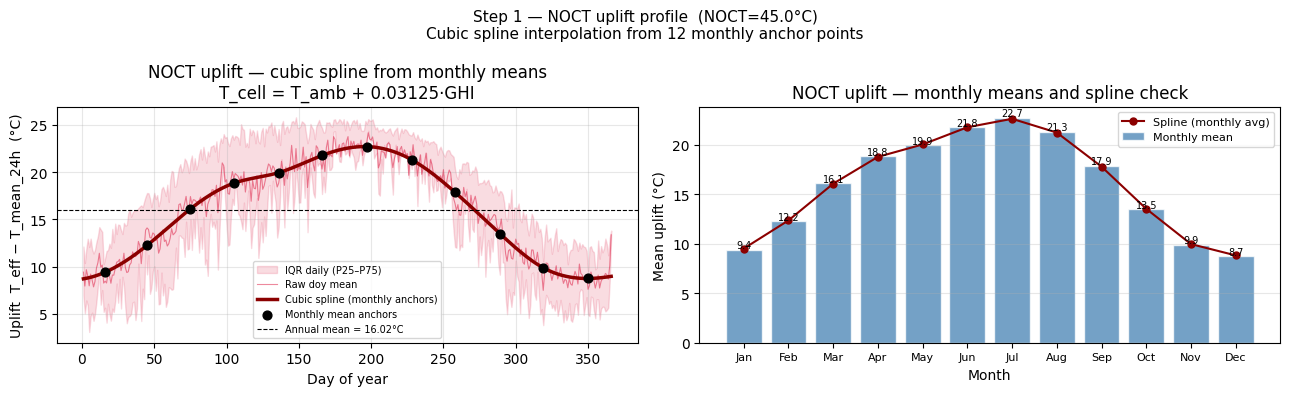

In [4]:
print(f"\n── Step 1: NOCT uplift profile ──────────────────────────────────")
print(f"  Computing from ERA5 hourly data (always recalculated)...")

noct_path = models_path / "Temperature" / "noct_uplift_params.pkl"

# ── load ERA5 hourly data ─────────────────────────────────────────────────────
era5_path = None
for candidate in [
    data_cleaned / "df_bologna_cleaned.parquet",
    data_modelled / "df_bologna_cleaned.parquet",
]:
    if candidate.exists():
        era5_path = candidate
        break

if era5_path is None:
    raise FileNotFoundError(
        "df_bologna_cleaned.parquet not found.\n"
        f"Searched in: {data_cleaned}  {data_modelled}"
    )

df_era5 = pd.read_parquet(era5_path)
df_era5["datetime"] = pd.to_datetime(df_era5["time"])
df_era5["date_only"] = df_era5["datetime"].dt.date

# confirm temperature in °C
if df_era5["t2m"].mean() > 100:
    df_era5["t2m"] = df_era5["t2m"] - 273.15
    print(f"  t2m converted from K to °C")

print(f"  ERA5 loaded : {len(df_era5):,} rows")
print(f"  Date range  : {df_era5['datetime'].min().date()} → "
      f"{df_era5['datetime'].max().date()}")
print(f"  t2m mean    : {df_era5['t2m'].mean():.2f}°C")
print(f"  GHI mean    : {df_era5['GHI'].mean():.1f} W/m²")

# ── NOCT hourly cell temperature ─────────────────────────────────────────────
NOCT_COEFF = (NOCT - 20) / 800   # °C per W/m²
df_era5["T_cell"] = df_era5["t2m"] + NOCT_COEFF * df_era5["GHI"]

# ── 24-hour daily mean T (all hours — before GHI filter) ─────────────────────
T_mean_24h = (
    df_era5.groupby("date_only")["t2m"]
    .mean()
    .rename("T_mean_24h")
)

# ── GHI-weighted daily effective cell temperature (daylight only) ─────────────
df_day = df_era5[df_era5["GHI"] > 0].copy()
print(f"  Daylight rows: {len(df_day):,}  "
      f"({len(df_day)/len(df_era5)*100:.1f}%)")

T_eff_daily = (
    df_day.groupby("date_only")
    .apply(lambda g: np.average(g["T_cell"], weights=g["GHI"]))
    .rename("T_eff_daily")
)

# ── daily uplift ──────────────────────────────────────────────────────────────
uplift_df = pd.DataFrame({
    "T_eff_daily": T_eff_daily,
    "T_mean_24h":  T_mean_24h,
}).dropna()
uplift_df["uplift"] = uplift_df["T_eff_daily"] - uplift_df["T_mean_24h"]
uplift_df.index     = pd.to_datetime(uplift_df.index)
uplift_df["doy"]    = uplift_df.index.dayofyear

# cap extreme uplift values
MAX_UPLIFT = 40
n_capped   = int((uplift_df["uplift"] > MAX_UPLIFT).sum())
uplift_df  = uplift_df[uplift_df["uplift"] <= MAX_UPLIFT].copy()
if n_capped > 0:
    print(f"  Capped {n_capped} days with uplift > {MAX_UPLIFT}°C")

# ── seasonal mean uplift by day-of-year ──────────────────────────────────────
uplift_by_doy = uplift_df.groupby("doy")["uplift"].mean().to_dict()

print(f"\n  NOCT uplift computed:")
print(f"    DOY entries  : {len(uplift_by_doy)}")
print(f"    Annual mean  : {np.mean(list(uplift_by_doy.values())):.2f}°C")
print(f"    Min (doy)    : "
      f"{min(uplift_by_doy.values()):.2f}°C  "
      f"doy={min(uplift_by_doy, key=uplift_by_doy.get)}")
print(f"    Max (doy)    : "
      f"{max(uplift_by_doy.values()):.2f}°C  "
      f"doy={max(uplift_by_doy, key=uplift_by_doy.get)}")
print(f"    Summer (JJA) : "
      f"{uplift_df[uplift_df['doy'].between(172,264)]['uplift'].mean():.2f}°C")
print(f"    Winter (DJF) : "
      f"{uplift_df[~uplift_df['doy'].between(60,334)]['uplift'].mean():.2f}°C")

# ── seasonal uplift: interpolate from monthly means → daily ───────────────────
# monthly means are more robust (600+ obs/month vs 20 obs/doy)
uplift_df["month"] = uplift_df.index.month
monthly_mean = uplift_df.groupby("month")["uplift"].mean()

# representative doy for each month midpoint
month_midday = {1:16, 2:45, 3:75, 4:105, 5:136, 6:166,
                7:197, 8:228, 9:258, 10:289, 11:319, 12:350}

# anchor points: month midpoint doy → monthly mean uplift
anchor_doys    = np.array([month_midday[m] for m in sorted(monthly_mean.index)])
anchor_uplifts = np.array([monthly_mean[m] for m in sorted(monthly_mean.index)])

# wrap-around for smooth interpolation at year boundaries
# prepend December anchor shifted back one year, append January shifted forward
doys_wrapped    = np.concatenate([anchor_doys[-1:] - 365,
                                   anchor_doys,
                                   anchor_doys[:1]  + 365])
uplifts_wrapped = np.concatenate([anchor_uplifts[-1:],
                                   anchor_uplifts,
                                   anchor_uplifts[:1]])

# cubic spline interpolation over full year
from scipy.interpolate import CubicSpline
cs = CubicSpline(doys_wrapped, uplifts_wrapped, bc_type="not-a-knot")
doys_full     = np.arange(1, 367)
uplift_smooth = cs(doys_full)

# build uplift_by_doy from smooth interpolated curve
uplift_by_doy = {int(doy): float(val)
                 for doy, val in zip(doys_full, uplift_smooth)}

print(f"\n  NOCT uplift — interpolated from monthly means:")
print(f"    DOY entries  : {len(uplift_by_doy)}")
print(f"    Annual mean  : {np.mean(list(uplift_by_doy.values())):.2f}°C")
print(f"    Min (doy)    : "
      f"{min(uplift_by_doy.values()):.2f}°C  "
      f"doy={min(uplift_by_doy, key=uplift_by_doy.get)}")
print(f"    Max (doy)    : "
      f"{max(uplift_by_doy.values()):.2f}°C  "
      f"doy={max(uplift_by_doy, key=uplift_by_doy.get)}")
print(f"    Summer (JJA) : "
      f"{np.mean([uplift_by_doy[d] for d in range(172,265)]):.2f}°C")
print(f"    Winter (DJF) : "
      f"{np.mean([uplift_by_doy.get(d,9.0) for d in list(range(1,60))+list(range(335,367))]):.2f}°C")

# monthly values for bar chart
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# ── updated plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: raw doy mean + smooth interpolated curve
ax = axes[0]
doys_raw  = np.array(sorted(
    uplift_df.groupby("doy")["uplift"].mean().to_dict().keys()
))
mean_raw  = np.array([
    uplift_df.groupby("doy")["uplift"].mean().to_dict()[d] for d in doys_raw
])
p25_raw   = uplift_df.groupby("doy")["uplift"].quantile(0.25).reindex(doys_raw).values
p75_raw   = uplift_df.groupby("doy")["uplift"].quantile(0.75).reindex(doys_raw).values

ax.fill_between(doys_raw, p25_raw, p75_raw,
                alpha=0.15, color="crimson", label="IQR daily (P25–P75)")
ax.plot(doys_raw, mean_raw,
        color="crimson", lw=0.8, alpha=0.5, label="Raw doy mean")
ax.plot(doys_full, uplift_smooth,
        color="darkred", lw=2.5, label="Cubic spline (monthly anchors)")
ax.scatter(anchor_doys, anchor_uplifts,
           color="black", s=40, zorder=5, label="Monthly mean anchors")
ax.axhline(np.mean(uplift_smooth), color="black", lw=0.8, ls="--",
           label=f"Annual mean = {np.mean(uplift_smooth):.2f}°C")
ax.set_xlabel("Day of year")
ax.set_ylabel("Uplift  T_eff − T_mean_24h  (°C)")
ax.set_title(f"NOCT uplift — cubic spline from monthly means\n"
             f"T_cell = T_amb + {NOCT_COEFF:.5f}·GHI")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# right: monthly bar chart with spline overlay
ax = axes[1]
bars = ax.bar(sorted(monthly_mean.index), monthly_mean.values,
              color="steelblue", alpha=0.75, edgecolor="white",
              label="Monthly mean")

# overlay spline as monthly mean from interpolated curve
# monthly average from interpolated spline

spline_monthly = {}
for m in range(1, 13):
    # get all doys belonging to this month in a non-leap year
    start_doy = sum(calendar.monthrange(2023, mm)[1] for mm in range(1, m)) + 1
    end_doy   = start_doy + calendar.monthrange(2023, m)[1]
    month_doys = [d for d in doys_full if start_doy <= d < end_doy]
    spline_monthly[m] = float(np.mean([uplift_by_doy[d] for d in month_doys]))
ax.plot(list(spline_monthly.keys()),
        list(spline_monthly.values()),
        "o-", color="darkred", lw=1.5, ms=5, label="Spline (monthly avg)")

ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Mean uplift (°C)")
ax.set_title("NOCT uplift — monthly means and spline check")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")
for bar, val in zip(bars, monthly_mean.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.15,
            f"{val:.1f}", ha="center", fontsize=7)

plt.suptitle(f"Step 1 — NOCT uplift profile  (NOCT={NOCT}°C)\n"
             f"Cubic spline interpolation from 12 monthly anchor points",
             fontsize=11)
plt.tight_layout()
plt.show()

In [5]:
# STEP 2 — Load physical variables and compute T_eff(t)
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 2: Load physical variables and compute T_eff(t) ─────────")
 
df_phys = pd.read_parquet(data_sim / "mc_physical_variables.parquet")
df_phys["date"] = pd.to_datetime(df_phys["date"])
 
N_SIM  = int(df_phys["sim_id"].nunique())
N_DAYS = int(df_phys.groupby("sim_id").size().iloc[0])
print(f"  Loaded  : {N_SIM} paths × {N_DAYS} days  ({len(df_phys):,} rows)")
 
# reshape to (N_SIM, N_DAYS)
df_sorted   = df_phys.sort_values(["sim_id", "date"]).reset_index(drop=True)
dates_sim   = np.sort(pd.to_datetime(df_sorted["date"].unique()))
dates_pd    = pd.DatetimeIndex(dates_sim)
years_arr   = dates_pd.year
doys_arr_sim = dates_pd.dayofyear
 
T_sim_arr   = df_sorted["T_sim"].values.reshape(N_SIM, N_DAYS)
GHI_sim_arr = df_sorted["GHI_sim"].values.reshape(N_SIM, N_DAYS)
CR_sim_arr  = df_sorted["CR_sim"].values.reshape(N_SIM, N_DAYS)
 
df_cal_ri = (
    df_sorted[df_sorted["sim_id"] == 0]
    [["date","year","month","doy","pen_scenario","mu_CR_sim","ghi_clearsky"]]
    .reset_index(drop=True)
)
print(f"  Date range : {dates_pd[0].date()} → {dates_pd[-1].date()}")
 
# ── apply NOCT seasonal uplift ────────────────────────────────────────────────
# deterministic uplift by day-of-year — same for all simulation paths
# stochastic variation comes from T_sim_arr differing across paths
uplift_sim = np.array([
    uplift_by_doy.get(int(doy), float(np.mean(list(uplift_by_doy.values()))))
    for doy in doys_arr_sim
])   # shape (N_DAYS,)
 
# broadcast (1, N_DAYS) across all N_SIM paths
T_eff_arr = T_sim_arr + uplift_sim[np.newaxis, :]   # shape (N_SIM, N_DAYS)
 
T_eff_flat  = T_eff_arr.ravel()
uplift_flat = (T_eff_arr - T_sim_arr).ravel()
 
print(f"\n  T_eff(t) = T_sim(t) + uplift_doy[doy(t)]  [NOCT model]:")
print(f"    uplift range  : [{uplift_sim.min():.2f}, {uplift_sim.max():.2f}]°C")
print(f"    uplift mean   : {uplift_sim.mean():.2f}°C")
print(f"    T_eff mean    : {T_eff_flat.mean():.2f}°C")
print(f"    T_eff p5      : {np.percentile(T_eff_flat,  5):.2f}°C")
print(f"    T_eff p95     : {np.percentile(T_eff_flat, 95):.2f}°C")
print(f"    T_eff max     : {T_eff_flat.max():.2f}°C  "
      f"(expected ~55–65°C on peak summer days)")
 
# sanity check: T_eff should always exceed T_sim
n_below = int(np.sum(T_eff_arr < T_sim_arr))
print(f"    T_eff < T_sim : {n_below} cases  "
      f"{'✓ none' if n_below == 0 else '✗ check uplift_by_doy'}")


── Step 2: Load physical variables and compute T_eff(t) ─────────


  Loaded  : 1000 paths × 9131 days  (9,131,000 rows)


  Date range : 2026-01-01 → 2050-12-31



  T_eff(t) = T_sim(t) + uplift_doy[doy(t)]  [NOCT model]:
    uplift range  : [8.70, 22.71]°C
    uplift mean   : 16.04°C
    T_eff mean    : 17.84°C


    T_eff p5      : -0.13°C
    T_eff p95     : 35.48°C


    T_eff max     : 48.51°C  (expected ~55–65°C on peak summer days)
    T_eff < T_sim : 0 cases  ✓ none


In [6]:
# STEP 3 — Compute production efficiency f_temp(t)
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 3: Compute f_temp(t) ─────────────────────────────────────")
 
f_temp_arr  = 1 + GAMMA * (T_eff_arr - T_STC)
f_temp_flat = f_temp_arr.ravel()
f_nz        = f_temp_flat[GHI_sim_arr.ravel() > 0]
 
print(f"  f_temp = 1 + ({GAMMA}) · (T_eff − {T_STC}):")
print(f"    mean (GHI>0) = {f_nz.mean():.5f}")
print(f"    p5  (GHI>0)  = {np.percentile(f_nz,  5):.5f}")
print(f"    p95 (GHI>0)  = {np.percentile(f_nz, 95):.5f}")
print(f"    min          = {f_temp_flat.min():.5f}  "
      f"(worst derating on hottest summer days)")
print(f"    max          = {f_temp_flat.max():.5f}  "
      f"(cold clear winter days)")
 
n_extreme = int(np.sum((f_temp_flat < 0.70) | (f_temp_flat > 1.10)))
print(f"  Extreme f_temp (<0.70 or >1.10): {n_extreme} days  "
      f"({n_extreme/len(f_temp_flat)*100:.3f}%)  "
      f"{'✓ negligible' if n_extreme/len(f_temp_flat) < 0.01 else '✗ check NOCT'}")


── Step 3: Compute f_temp(t) ─────────────────────────────────────


  f_temp = 1 + (-0.0043) · (T_eff − 25.0):
    mean (GHI>0) = 1.03081


    p5  (GHI>0)  = 0.95495
    p95 (GHI>0)  = 1.10805
    min          = 0.89890  (worst derating on hottest summer days)


    max          = 1.17746  (cold clear winter days)
  Extreme f_temp (<0.70 or >1.10): 1089423 days  (11.931%)  ✗ check NOCT


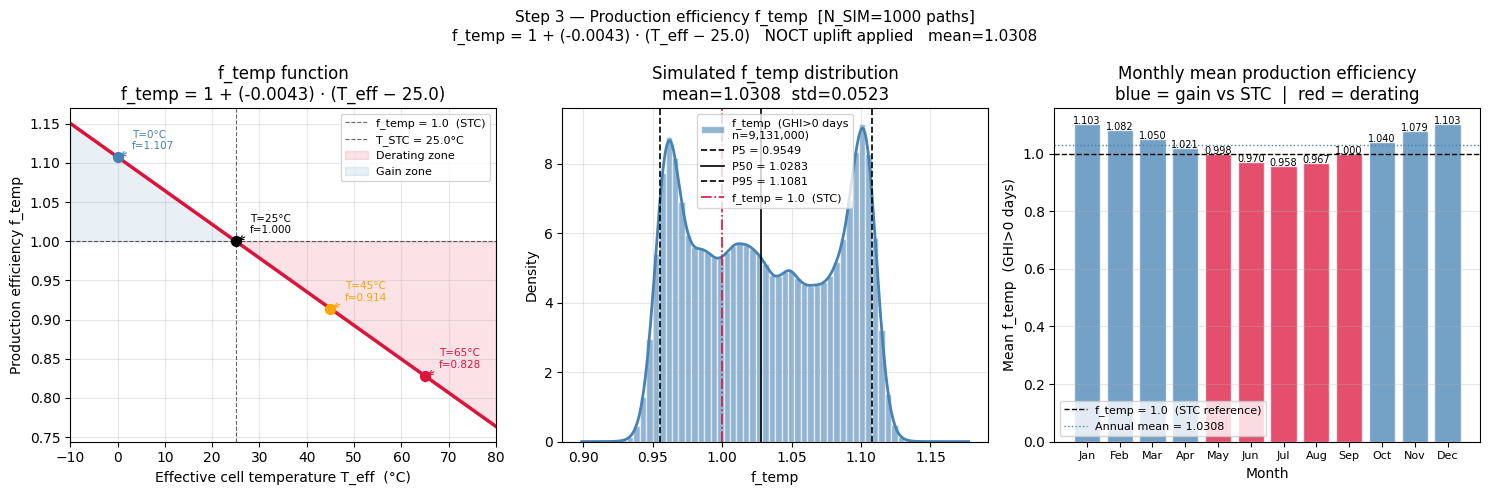

In [7]:
# ── f_temp diagnostic plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── left: f_temp function curve ───────────────────────────────────────────────
ax = axes[0]
T_range = np.linspace(-10, 80, 300)
f_range = 1 + GAMMA * (T_range - T_STC)

ax.plot(T_range, f_range, color="crimson", lw=2.5)
ax.axhline(1.0,  color="black",     lw=0.8, ls="--", alpha=0.6,
           label="f_temp = 1.0  (STC)")
ax.axvline(T_STC, color="black",    lw=0.8, ls="--", alpha=0.6,
           label=f"T_STC = {T_STC}°C")

# annotate key temperatures
for T_ann, color_ann in [(0, "steelblue"), (25, "black"),
                          (45, "orange"),  (65, "crimson")]:
    f_ann = 1 + GAMMA * (T_ann - T_STC)
    ax.scatter([T_ann], [f_ann], s=50, color=color_ann, zorder=5)
    ax.annotate(f"T={T_ann}°C\nf={f_ann:.3f}",
                xy=(T_ann, f_ann),
                xytext=(T_ann + 3, f_ann + 0.01),
                fontsize=7.5, color=color_ann,
                arrowprops=dict(arrowstyle="->",
                                color=color_ann, lw=0.8))

ax.fill_between(T_range, f_range, 1.0,
                where=f_range < 1.0,
                alpha=0.12, color="crimson", label="Derating zone")
ax.fill_between(T_range, f_range, 1.0,
                where=f_range > 1.0,
                alpha=0.12, color="steelblue", label="Gain zone")
ax.set_xlabel("Effective cell temperature T_eff  (°C)")
ax.set_ylabel("Production efficiency f_temp")
ax.set_title(f"f_temp function\n"
             f"f_temp = 1 + ({GAMMA}) · (T_eff − {T_STC})")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(-10, 80)

# ── middle: simulated f_temp distribution (GHI>0 days only) ──────────────────
ax = axes[1]
ax.hist(f_nz, bins=60, density=True,
        color="steelblue", alpha=0.6, edgecolor="white",
        label=f"f_temp  (GHI>0 days\nn={len(f_nz):,})")

kde_f  = gaussian_kde(f_nz)
x_kde  = np.linspace(f_nz.min(), f_nz.max(), 300)
ax.plot(x_kde, kde_f(x_kde), color="steelblue", lw=2.0)

for pct, ls, color in [(5, "--", "black"), (50, "-", "black"),
                        (95, "--", "black")]:
    val = np.percentile(f_nz, pct)
    ax.axvline(val, color=color, lw=1.2, ls=ls,
               label=f"P{pct} = {val:.4f}")
ax.axvline(1.0, color="crimson", lw=1.2, ls="-.",
           label="f_temp = 1.0  (STC)")

ax.set_xlabel("f_temp")
ax.set_ylabel("Density")
ax.set_title(f"Simulated f_temp distribution\n"
             f"mean={f_nz.mean():.4f}  "
             f"std={f_nz.std():.4f}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── right: monthly mean f_temp ────────────────────────────────────────────────
ax = axes[2]

# build monthly f_temp means from simulation
f_temp_flat_all = f_temp_arr.ravel()
ghi_flat_all    = GHI_sim_arr.ravel()
months_arr_sim  = np.tile(dates_pd.month, N_SIM)

monthly_f = {}
for m in range(1, 13):
    mask_m = (months_arr_sim == m) & (ghi_flat_all > 0)
    monthly_f[m] = float(np.mean(f_temp_flat_all[mask_m]))

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
colors_bar  = ["steelblue" if v >= 1.0 else "crimson"
               for v in monthly_f.values()]
bars = ax.bar(range(1, 13), monthly_f.values(),
              color=colors_bar, alpha=0.75, edgecolor="white")
ax.axhline(1.0, color="black", lw=1.0, ls="--",
           label="f_temp = 1.0  (STC reference)")
ax.axhline(f_nz.mean(), color="steelblue", lw=1.0, ls=":",
           label=f"Annual mean = {f_nz.mean():.4f}")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Mean f_temp  (GHI>0 days)")
ax.set_title("Monthly mean production efficiency\n"
             "blue = gain vs STC  |  red = derating")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")
for bar, val in zip(bars, monthly_f.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f"{val:.3f}", ha="center", fontsize=7)

plt.suptitle(
    f"Step 3 — Production efficiency f_temp  [N_SIM={N_SIM} paths]\n"
    f"f_temp = 1 + ({GAMMA}) · (T_eff − {T_STC})   "
    f"NOCT uplift applied   "
    f"mean={f_nz.mean():.4f}",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [8]:
# STEP 4 — Compute unit energy yield P(t)  [kWh/kWp/day]
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 4: Compute P(t) ─────────────────────────────────────────")
 
P_arr  = (GHI_sim_arr / G_STC) * f_temp_arr * PR
P_flat = P_arr.ravel()
P_nz   = P_flat[P_flat > 0]
 
print(f"  P(t) = (GHI_sim/{G_STC}) · f_temp · {PR}  [kWh/kWp/day]:")
print(f"    mean (P>0)  = {P_nz.mean():.4f} kWh/kWp")
print(f"    p50  (P>0)  = {np.percentile(P_nz, 50):.4f} kWh/kWp")
print(f"    p95  (P>0)  = {np.percentile(P_nz, 95):.4f} kWh/kWp")

# replace with:
n_years = len(np.unique(years_arr))
annual_yield_mean = P_arr.sum(axis=1).mean() / n_years
print(f"    Total 25yr  = {P_arr.sum(axis=1).mean():.1f} kWh/kWp  "
      f"(sum over all {N_DAYS} simulation days)")
print(f"    Annual mean = {annual_yield_mean:.1f} kWh/kWp/year  ")
 


── Step 4: Compute P(t) ─────────────────────────────────────────
  P(t) = (GHI_sim/1000.0) · f_temp · 0.8  [kWh/kWp/day]:


    mean (P>0)  = 3.3205 kWh/kWp
    p50  (P>0)  = 3.1553 kWh/kWp


    p95  (P>0)  = 6.2175 kWh/kWp
    Total 25yr  = 30319.8 kWh/kWp  (sum over all 9131 simulation days)
    Annual mean = 1212.8 kWh/kWp/year  


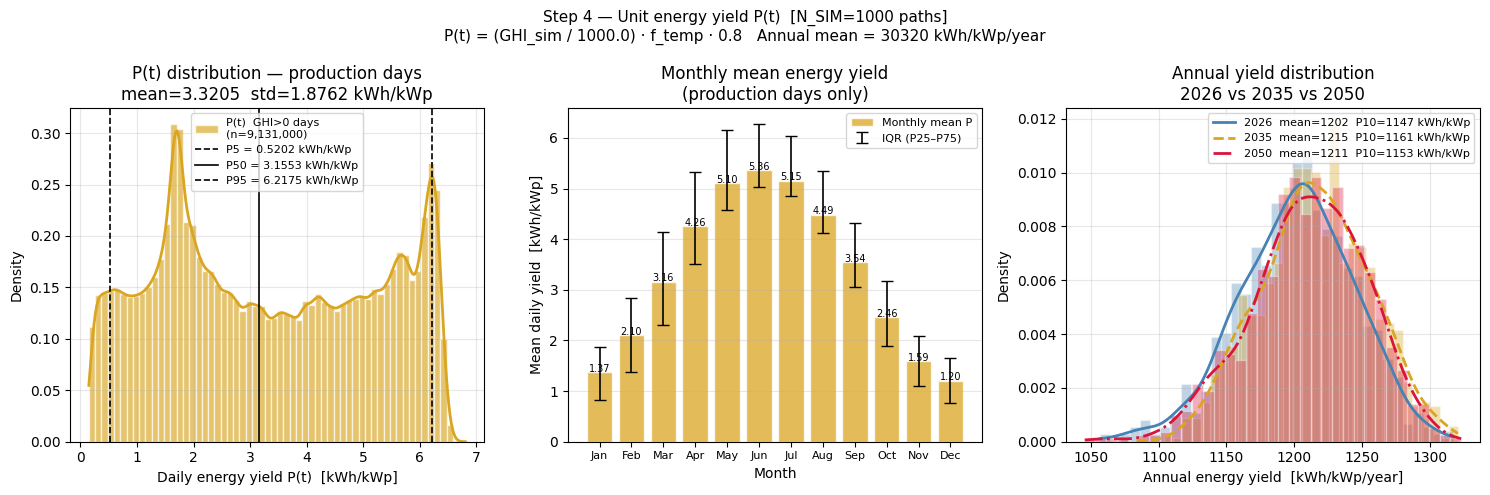

In [9]:
# ── P(t) distribution plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── left: overall P distribution (production days only) ──────────────────────
ax = axes[0]
ax.hist(P_nz, bins=60, density=True,
        color="goldenrod", alpha=0.65, edgecolor="white",
        label=f"P(t)  GHI>0 days\n(n={len(P_nz):,})")

kde_p  = gaussian_kde(P_nz)
x_kde  = np.linspace(P_nz.min(), P_nz.max(), 300)
ax.plot(x_kde, kde_p(x_kde), color="goldenrod", lw=2.0)

for pct, ls in [(5,"--"), (50,"-"), (95,"--")]:
    val = np.percentile(P_nz, pct)
    ax.axvline(val, color="black", lw=1.2, ls=ls,
               label=f"P{pct} = {val:.4f} kWh/kWp")

ax.set_xlabel("Daily energy yield P(t)  [kWh/kWp]")
ax.set_ylabel("Density")
ax.set_title(f"P(t) distribution — production days\n"
             f"mean={P_nz.mean():.4f}  std={P_nz.std():.4f} kWh/kWp")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── middle: monthly mean P ────────────────────────────────────────────────────
ax = axes[1]
months_sim = np.tile(dates_pd.month, N_SIM)
P_flat_all = P_arr.ravel()

monthly_P_mean = {}
monthly_P_p25  = {}
monthly_P_p75  = {}
for m in range(1, 13):
    mask_m = (months_sim == m) & (P_flat_all > 0)
    vals   = P_flat_all[mask_m]
    monthly_P_mean[m] = float(np.mean(vals))
    monthly_P_p25[m]  = float(np.percentile(vals, 25))
    monthly_P_p75[m]  = float(np.percentile(vals, 75))

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
months_x    = np.array(range(1, 13))

bars = ax.bar(months_x, monthly_P_mean.values(),
              color="goldenrod", alpha=0.75, edgecolor="white",
              label="Monthly mean P")
ax.errorbar(months_x,
            list(monthly_P_mean.values()),
            yerr=[
                [monthly_P_mean[m] - monthly_P_p25[m] for m in range(1,13)],
                [monthly_P_p75[m]  - monthly_P_mean[m] for m in range(1,13)],
            ],
            fmt="none", color="black", lw=1.2, capsize=4,
            label="IQR (P25–P75)")
ax.set_xticks(months_x)
ax.set_xticklabels(month_names, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily yield  [kWh/kWp]")
ax.set_title("Monthly mean energy yield\n(production days only)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")
for bar, val in zip(bars, monthly_P_mean.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", fontsize=7)

# ── right: annual P distribution — 2026 vs 2050 ──────────────────────────────
ax = axes[2]
for yr, color, ls in [(2026, "steelblue", "-"),
                       (2035, "goldenrod",  "--"),
                       (2050, "crimson",    "-.")]:
    mask_yr  = years_arr == yr
    P_yr_ann = P_arr[:, mask_yr].sum(axis=1)   # annual yield per path
    ax.hist(P_yr_ann, bins=35, density=True,
            color=color, alpha=0.35, edgecolor="white")
    kde_yr = gaussian_kde(P_yr_ann)
    x_yr   = np.linspace(P_yr_ann.min(), P_yr_ann.max(), 200)
    ax.plot(x_yr, kde_yr(x_yr), color=color, lw=2.0, ls=ls,
            label=f"{yr}  mean={P_yr_ann.mean():.0f}  "
                  f"P10={np.percentile(P_yr_ann,10):.0f} kWh/kWp")

ax.set_xlabel("Annual energy yield  [kWh/kWp/year]")
ax.set_ylabel("Density")
ax.set_title("Annual yield distribution\n2026 vs 2035 vs 2050")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(
    f"Step 4 — Unit energy yield P(t)  [N_SIM={N_SIM} paths]\n"
    f"P(t) = (GHI_sim / {G_STC}) · f_temp · {PR}   "
    f"Annual mean = {P_arr.sum(axis=1).mean():.0f} kWh/kWp/year",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [10]:
# STEP 5 — Compute daily revenue index RI(t)
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 5: Compute RI(t) ────────────────────────────────────────")
 
RI_arr  = P_arr * CR_sim_arr
RI_flat = RI_arr.ravel()
RI_nz   = RI_flat[RI_flat > 0]
 
print(f"  RI(t) = P(t) · CR_sim(t)  [kWh/kWp · CR]:")
print(f"    mean (RI>0) = {RI_nz.mean():.4f}")
print(f"    p5  (RI>0)  = {np.percentile(RI_nz,  5):.4f}")
print(f"    p50 (RI>0)  = {np.percentile(RI_nz, 50):.4f}")
print(f"    p95 (RI>0)  = {np.percentile(RI_nz, 95):.4f}")
print(f"    max         = {RI_flat.max():.4f}")
 
print(f"\n  Decomposition check (2026 annual means):")
mask_2026 = years_arr == 2026
print(f"    P_annual  = {P_arr[:, mask_2026].sum(axis=1).mean():.2f} kWh/kWp")
print(f"    CR_mean   = {CR_sim_arr[:, mask_2026].mean():.4f}")
print(f"    RI_annual = {RI_arr[:, mask_2026].sum(axis=1).mean():.2f}")


── Step 5: Compute RI(t) ────────────────────────────────────────


  RI(t) = P(t) · CR_sim(t)  [kWh/kWp · CR]:
    mean (RI>0) = 2.1870
    p5  (RI>0)  = 0.3295


    p50 (RI>0)  = 1.9492


    p95 (RI>0)  = 4.7943
    max         = 13.1724

  Decomposition check (2026 annual means):
    P_annual  = 1201.76 kWh/kWp
    CR_mean   = 0.8914
    RI_annual = 1064.12



── Step 5B: Historical RI ───────────────────────────────────────


  CR hist   : 7670 rows  2005-01-01 → 2025-12-31
  Temp hist : 7670 rows  2005-01-01 → 2025-12-31
  GHI col   : 'ghi_sum'
  CR col    : 'capture_rate'
  T col     : 't2m_mean'

  Merged historical dataset:
    Rows  : 7670
    Range : 2005-01-01 → 2025-12-31
    GHI   : mean=4083.2 Wh/m²
    CR    : mean=1.0584
    T     : mean=13.30°C

  Historical RI daily statistics:
    mean (RI>0) = 3.2795
    p5  (RI>0)  = 0.5849
    p50 (RI>0)  = 3.0625
    p95 (RI>0)  = 6.5399



  Historical annual RI:
    Year   RI_annual    P_annual    CR_mean   n_days
  ------  ----------  ----------  ---------  -------
    2005     1423.85     1108.32     1.2684      365
    2006     1453.04     1139.23     1.2399      365
    2007     1491.86     1157.02     1.2616      365
    2008     1345.21     1111.85     1.1923      366
    2009     1393.79     1116.72     1.2185      365
    2010     1219.24     1079.24     1.1166      365
    2011     1275.90     1199.15     1.0611      365
    2012     1140.77     1164.63     0.9907      366
    2013     1032.38     1089.67     0.9768      365
    2014     1049.55     1083.89     0.9952      365
    2015     1165.98     1150.69     1.0249      365
    2016     1140.38     1110.95     1.0363      366
    2017     1223.99     1213.66     1.0225      365
    2018     1113.47     1107.63     1.0218      365
    2019     1157.23     1153.38     1.0180      365
    2020     1161.20     1202.62     0.9937      366
    2021     1156.20 

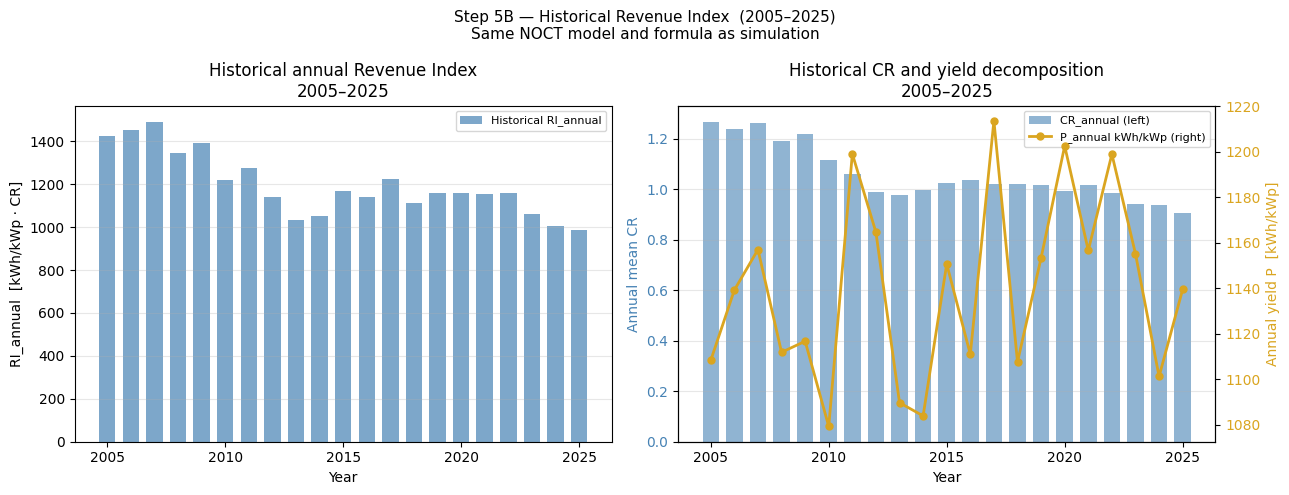

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5B — Historical RI computation
# ─────────────────────────────────────────────────────────────────────────────
# Compute RI on historical observed data (2005–2025) using the same
# formulas as the simulation — for validation and comparison.
#
# Sources:
#   GHI       : df_cr_modelled.parquet  (ghi_sum column)
#   CR        : df_cr_modelled.parquet  (capture_rate column)
#   T_mean_24h: df_temperature_modeled.parquet (daily mean)
#   T_eff     : T_mean_24h + uplift_by_doy[doy]  (same NOCT profile)

print(f"\n── Step 5B: Historical RI ───────────────────────────────────────")

# ── load historical modelled data ─────────────────────────────────────────────
df_cr_hist = pd.read_parquet(data_modelled / "df_cr_modelled.parquet")
df_cr_hist["date"] = pd.to_datetime(df_cr_hist["date"])
df_cr_hist = df_cr_hist.sort_values("date").reset_index(drop=True)

df_temp_hist = pd.read_parquet(data_modelled / "df_temperature_modeled.parquet")
df_temp_hist["date"] = pd.to_datetime(df_temp_hist["date"])
df_temp_hist = df_temp_hist.sort_values("date").reset_index(drop=True)

print(f"  CR hist   : {len(df_cr_hist)} rows  "
      f"{df_cr_hist['date'].min().date()} → "
      f"{df_cr_hist['date'].max().date()}")
print(f"  Temp hist : {len(df_temp_hist)} rows  "
      f"{df_temp_hist['date'].min().date()} → "
      f"{df_temp_hist['date'].max().date()}")

# ── fixed column names ───────────────────────────────────────────────────────
# df_cr_modelled.parquet  : ghi_sum, capture_rate
# df_temperature_modeled  : t2m_mean (24-hour daily mean)
ghi_hist_col = "ghi_sum"       # Wh/m2 daily GHI sum
cr_hist_col  = "capture_rate"  # observed daily capture rate
t_hist_col   = "t2m_mean"      # 24-hour daily mean temperature C

# verify columns exist before proceeding
for col, df, label in [
    (ghi_hist_col, df_cr_hist,   "df_cr_modelled"),
    (cr_hist_col,  df_cr_hist,   "df_cr_modelled"),
    (t_hist_col,   df_temp_hist, "df_temperature_modeled"),
]:
    if col not in df.columns:
        raise KeyError(
            f"Column {col!r} not found in {label}."
            f"Available: {list(df.columns)}"
        )

print(f"  GHI col   : '{ghi_hist_col}'")
print(f"  CR col    : '{cr_hist_col}'")
print(f"  T col     : '{t_hist_col}'")

# ── merge on date ─────────────────────────────────────────────────────────────
df_hist = df_cr_hist[["date", ghi_hist_col, cr_hist_col]].copy()
df_hist = df_hist.merge(
    df_temp_hist[["date", t_hist_col]],
    on="date", how="inner"
)
df_hist = df_hist.rename(columns={
    ghi_hist_col: "GHI_hist",
    cr_hist_col:  "CR_hist",
    t_hist_col:   "T_hist",
})

# ── drop rows with missing values before any computation ──────────────────────
n_before = len(df_hist)
df_hist  = df_hist.dropna(
    subset=["GHI_hist", "CR_hist", "T_hist"]
).copy().reset_index(drop=True)
n_after  = len(df_hist)
if n_before > n_after:
    print(f"  Dropped {n_before - n_after} rows with NaN values")

# ── calendar variables ────────────────────────────────────────────────────────
df_hist["year"]  = df_hist["date"].dt.year
df_hist["month"] = df_hist["date"].dt.month
df_hist["doy"]   = df_hist["date"].dt.dayofyear

print(f"\n  Merged historical dataset:")
print(f"    Rows  : {len(df_hist)}")
print(f"    Range : {df_hist['date'].min().date()} → "
      f"{df_hist['date'].max().date()}")
print(f"    GHI   : mean={df_hist['GHI_hist'].mean():.1f} Wh/m²")
print(f"    CR    : mean={df_hist['CR_hist'].mean():.4f}")
print(f"    T     : mean={df_hist['T_hist'].mean():.2f}°C")

# ── apply NOCT uplift ─────────────────────────────────────────────────────────
uplift_default = float(np.mean(list(uplift_by_doy.values())))

df_hist["uplift"] = df_hist["doy"].apply(
    lambda d: uplift_by_doy.get(int(d), uplift_default)
    if pd.notna(d) else uplift_default
)

df_hist["T_eff"]  = df_hist["T_hist"] + df_hist["uplift"]

# ── production efficiency ─────────────────────────────────────────────────────
df_hist["f_temp"] = 1 + GAMMA * (df_hist["T_eff"] - T_STC)

# ── unit energy yield ─────────────────────────────────────────────────────────
df_hist["P_hist"] = (
    (df_hist["GHI_hist"] / G_STC) * df_hist["f_temp"] * PR
)

# ── daily RI ──────────────────────────────────────────────────────────────────
df_hist["RI_hist"] = df_hist["P_hist"] * df_hist["CR_hist"]

print(f"\n  Historical RI daily statistics:")
ri_nz_hist = df_hist.loc[df_hist["RI_hist"] > 0, "RI_hist"]
print(f"    mean (RI>0) = {ri_nz_hist.mean():.4f}")
print(f"    p5  (RI>0)  = {ri_nz_hist.quantile(0.05):.4f}")
print(f"    p50 (RI>0)  = {ri_nz_hist.quantile(0.50):.4f}")
print(f"    p95 (RI>0)  = {ri_nz_hist.quantile(0.95):.4f}")

# ── aggregate to annual ───────────────────────────────────────────────────────
df_hist_annual = (
    df_hist.groupby("year")
    .agg(
        RI_annual    = ("RI_hist",  "sum"),
        P_annual     = ("P_hist",   "sum"),
        CR_annual    = ("CR_hist",  "mean"),
        T_annual     = ("T_hist",   "mean"),
        T_eff_annual = ("T_eff",    "mean"),
        GHI_annual   = ("GHI_hist", "sum"),
        n_days       = ("date",     "count"),
    )
    .reset_index()
)

print(f"\n  Historical annual RI:")
print(f"  {'Year':>6}  {'RI_annual':>10}  {'P_annual':>10}  "
      f"{'CR_mean':>9}  {'n_days':>7}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  "
      f"{'-'*9}  {'-'*7}")
for _, row in df_hist_annual.iterrows():
    print(f"  {int(row['year']):>6}  "
          f"{row['RI_annual']:>10.2f}  "
          f"{row['P_annual']:>10.2f}  "
          f"{row['CR_annual']:>9.4f}  "
          f"{int(row['n_days']):>7}")

# ── save ──────────────────────────────────────────────────────────────────────
out_hist = data_results / "ri_annual_results_hist.parquet"
df_hist_annual.to_parquet(out_hist, index=False, compression="snappy")
print(f"\n  Saved : {out_hist}")
print(f"  Rows  : {len(df_hist_annual)}  "
      f"({int(df_hist_annual['year'].min())}–"
      f"{int(df_hist_annual['year'].max())})")
print(f"  Cols  : {list(df_hist_annual.columns)}")

# ── comparison plot: historical vs simulated 2026 ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: annual RI time series ───────────────────────────────────────────────
ax = axes[0]
ax.bar(df_hist_annual["year"], df_hist_annual["RI_annual"],
       color="steelblue", alpha=0.70, width=0.7,
       label="Historical RI_annual")

# overlay simulated 2026 distribution if Step 6 has already run
if "df_annual" in dir():
    ri_2026 = df_annual[df_annual["year"] == 2026]["RI_annual"]
    ax.axhline(ri_2026.mean(),
               color="crimson", lw=1.5, ls="--",
               label=f"Sim 2026 mean = {ri_2026.mean():.1f}")
    ax.axhspan(ri_2026.quantile(0.10), ri_2026.quantile(0.90),
               alpha=0.12, color="crimson",
               label=f"Sim 2026 P10–P90")

ax.set_xlabel("Year")
ax.set_ylabel("RI_annual  [kWh/kWp · CR]")
ax.set_title("Historical annual Revenue Index\n2005–2025")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

# ── right: historical CR and yield decomposition ──────────────────────────────
ax  = axes[1]
ax2 = ax.twinx()

ax.bar(df_hist_annual["year"], df_hist_annual["CR_annual"],
       color="steelblue", alpha=0.60, width=0.7,
       label="CR_annual (left)")
ax2.plot(df_hist_annual["year"], df_hist_annual["P_annual"],
         "o-", color="goldenrod", lw=2.0, ms=5,
         label="P_annual kWh/kWp (right)")

ax.set_xlabel("Year")
ax.set_ylabel("Annual mean CR", color="steelblue")
ax2.set_ylabel("Annual yield P  [kWh/kWp]", color="goldenrod")
ax.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="goldenrod")
ax.set_title("Historical CR and yield decomposition\n2005–2025")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.grid(alpha=0.3, axis="y")

plt.suptitle(
    f"Step 5B — Historical Revenue Index  (2005–2025)\n"
    f"Same NOCT model and formula as simulation",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [12]:
df_temp_hist.columns

Index(['date', 't2m_mean', 't2m_min', 't2m_max', 't2m_range', 'arch_resid',
       'arch_std_resid', 'arch_cond_vol', 'arch_predicted'],
      dtype='str')


── Step 6: Annual aggregation and save ──────────────────────────


  Annual dataframe: 25,000 rows  (1000 paths × 25 years)

    Year    RI mean    RI P10    RI P50    RI P90     P mean    CR mean
  ------  ---------  --------  --------  --------  ---------  ---------
    2026    1064.12   1001.81   1065.71   1121.71    1201.76     0.8914
    2030    1021.56    965.10   1021.29   1078.50    1215.07     0.8462
    2035     786.85    734.63    786.54    839.43    1215.01     0.6529
    2040     676.91    624.81    678.04    726.63    1214.04     0.5637
    2045     673.62    621.72    674.02    725.75    1210.40     0.5625
    2050     672.93    622.64    671.44    722.43    1210.50     0.5619

  Saved: ..\..\Data\Results\ri_annual_results.parquet  (1.3 MB)


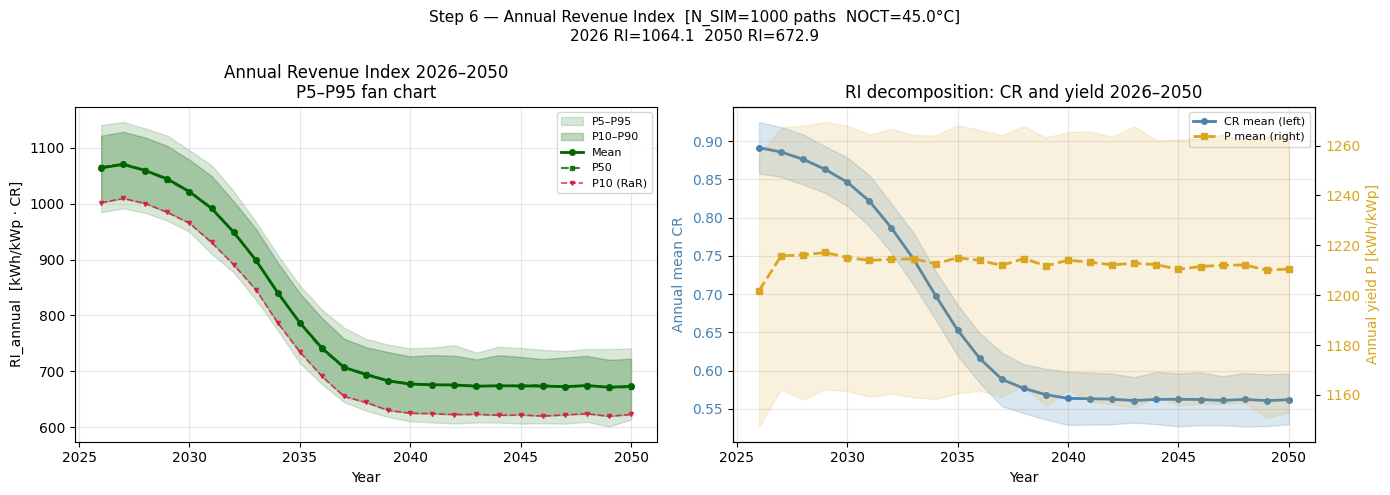


── Steps 0–6 complete ───────────────────────────────────────────
  T_eff method : NOCT  (NOCT=45.0°C  no regression)
  Uplift range : [8.70, 22.71]°C  mean=16.04°C
  Output saved : ..\..\Data\Results\ri_annual_results.parquet
  Rows         : 25,000
  Columns      : ['sim_id', 'year', 'RI_annual', 'P_annual', 'CR_annual', 'T_annual', 'T_eff_annual', 'GHI_annual']

  → Next: risk metrics notebook
    Load: ..\..\Data\Results\ri_annual_results.parquet


In [13]:
# STEP 6 — Aggregate to annual and save
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 6: Annual aggregation and save ──────────────────────────")
 
years_unique = sorted(np.unique(years_arr))
records      = []
 
for yr in years_unique:
    mask   = years_arr == yr
    RI_yr  = RI_arr[:,       mask].sum(axis=1)
    P_yr   = P_arr[:,        mask].sum(axis=1)
    CR_yr  = CR_sim_arr[:,   mask].mean(axis=1)
    T_yr   = T_sim_arr[:,    mask].mean(axis=1)
    Teff_yr= T_eff_arr[:,    mask].mean(axis=1)
    GHI_yr = GHI_sim_arr[:, mask].sum(axis=1)
 
    for sim_id in range(N_SIM):
        records.append({
            "sim_id":       int(sim_id),
            "year":         int(yr),
            "RI_annual":    float(RI_yr[sim_id]),
            "P_annual":     float(P_yr[sim_id]),
            "CR_annual":    float(CR_yr[sim_id]),
            "T_annual":     float(T_yr[sim_id]),
            "T_eff_annual": float(Teff_yr[sim_id]),
            "GHI_annual":   float(GHI_yr[sim_id]),
        })
 
df_annual = pd.DataFrame(records)
 
print(f"  Annual dataframe: {len(df_annual):,} rows  "
      f"({N_SIM} paths × {len(years_unique)} years)")
 
print(f"\n  {'Year':>6}  {'RI mean':>9}  {'RI P10':>8}  "
      f"{'RI P50':>8}  {'RI P90':>8}  {'P mean':>9}  {'CR mean':>9}")
print(f"  {'-'*6}  {'-'*9}  {'-'*8}  "
      f"{'-'*8}  {'-'*8}  {'-'*9}  {'-'*9}")
for yr in [2026, 2030, 2035, 2040, 2045, 2050]:
    d = df_annual[df_annual["year"] == yr]
    print(f"  {yr:>6}  "
          f"{d['RI_annual'].mean():>9.2f}  "
          f"{d['RI_annual'].quantile(0.10):>8.2f}  "
          f"{d['RI_annual'].quantile(0.50):>8.2f}  "
          f"{d['RI_annual'].quantile(0.90):>8.2f}  "
          f"{d['P_annual'].mean():>9.2f}  "
          f"{d['CR_annual'].mean():>9.4f}")
 
# ── save ──────────────────────────────────────────────────────────────────────
out_annual = data_results / "ri_annual_results.parquet"
df_annual.to_parquet(out_annual, index=False, compression="snappy")
print(f"\n  Saved: {out_annual}  "
      f"({out_annual.stat().st_size/1e6:.1f} MB)")
 
# ── fan chart ─────────────────────────────────────────────────────────────────
ri_stats = (
    df_annual.groupby("year")["RI_annual"]
    .agg(
        mean = "mean",
        p5   = lambda x: x.quantile(0.05),
        p10  = lambda x: x.quantile(0.10),
        p50  = lambda x: x.quantile(0.50),
        p90  = lambda x: x.quantile(0.90),
        p95  = lambda x: x.quantile(0.95),
    )
    .reset_index()
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# ── left: RI annual fan chart ─────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(ri_stats["year"], ri_stats["p5"],  ri_stats["p95"],
                alpha=0.15, color="darkgreen", label="P5–P95")
ax.fill_between(ri_stats["year"], ri_stats["p10"], ri_stats["p90"],
                alpha=0.25, color="darkgreen", label="P10–P90")
ax.plot(ri_stats["year"], ri_stats["mean"], "o-",
        color="darkgreen", lw=2.0, ms=4, label="Mean")
ax.plot(ri_stats["year"], ri_stats["p50"],  "s--",
        color="darkgreen", lw=1.5, ms=3, alpha=0.8, label="P50")
ax.plot(ri_stats["year"], ri_stats["p10"],  "v--",
        color="crimson",   lw=1.2, ms=3, alpha=0.8, label="P10 (RaR)")
ax.set_xlabel("Year")
ax.set_ylabel("RI_annual  [kWh/kWp · CR]")
ax.set_title("Annual Revenue Index 2026–2050\nP5–P95 fan chart")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
 
# ── right: CR and P decomposition ─────────────────────────────────────────────
ax  = axes[1]
ax2 = ax.twinx()
 
cr_stats = (
    df_annual.groupby("year")["CR_annual"]
    .agg(mean="mean",
         p10=lambda x: x.quantile(0.10),
         p90=lambda x: x.quantile(0.90))
    .reset_index()
)
p_stats = (
    df_annual.groupby("year")["P_annual"]
    .agg(mean="mean",
         p10=lambda x: x.quantile(0.10),
         p90=lambda x: x.quantile(0.90))
    .reset_index()
)
 
ax.fill_between(cr_stats["year"],
                cr_stats["p10"], cr_stats["p90"],
                alpha=0.20, color="steelblue")
ax.plot(cr_stats["year"], cr_stats["mean"], "o-",
        color="steelblue", lw=2.0, ms=4, label="CR mean (left)")
ax2.fill_between(p_stats["year"],
                 p_stats["p10"], p_stats["p90"],
                 alpha=0.15, color="goldenrod")
ax2.plot(p_stats["year"], p_stats["mean"], "s--",
         color="goldenrod", lw=2.0, ms=4, label="P mean (right)")
 
ax.set_xlabel("Year")
ax.set_ylabel("Annual mean CR", color="steelblue")
ax2.set_ylabel("Annual yield P [kWh/kWp]", color="goldenrod")
ax.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="goldenrod")
ax.set_title("RI decomposition: CR and yield 2026–2050")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
 
plt.suptitle(
    f"Step 6 — Annual Revenue Index  [N_SIM={N_SIM} paths  NOCT={NOCT}°C]\n"
    f"2026 RI={df_annual[df_annual['year']==2026]['RI_annual'].mean():.1f}  "
    f"2050 RI={df_annual[df_annual['year']==2050]['RI_annual'].mean():.1f}",
    fontsize=11
)
plt.tight_layout()
plt.show()
 
print(f"\n── Steps 0–6 complete ───────────────────────────────────────────")
print(f"  T_eff method : NOCT  (NOCT={NOCT}°C  no regression)")
print(f"  Uplift range : [{uplift_sim.min():.2f}, {uplift_sim.max():.2f}]°C  "
      f"mean={uplift_sim.mean():.2f}°C")
print(f"  Output saved : {out_annual}")
print(f"  Rows         : {len(df_annual):,}")
print(f"  Columns      : {list(df_annual.columns)}")
print(f"\n  → Next: risk metrics notebook")
print(f"    Load: {out_annual}")

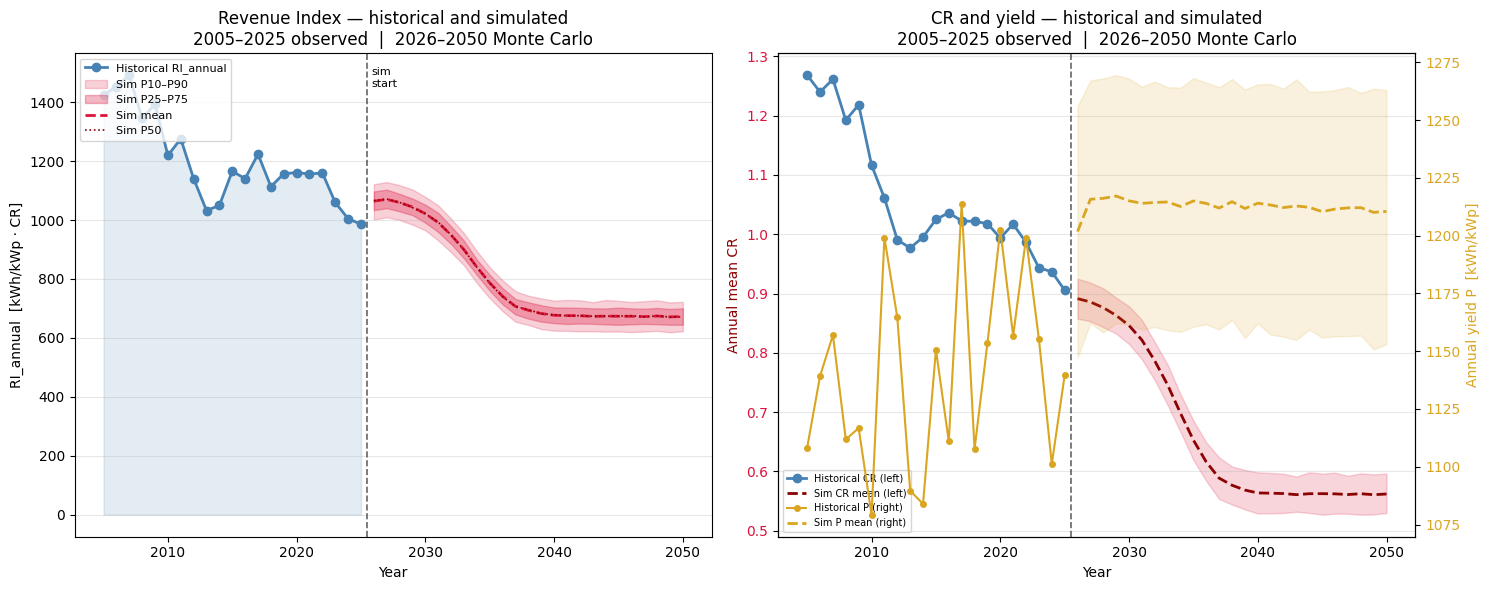

In [14]:
# ── historical vs simulated RI fan chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── left: annual RI — historical bars + simulated fan ────────────────────────
ax = axes[0]

# historical bars
ax.plot(df_hist_annual["year"], df_hist_annual["RI_annual"],
        "o-", color="steelblue", lw=2.0, ms=6,
        zorder=4, label="Historical RI_annual")
ax.fill_between(df_hist_annual["year"],
                df_hist_annual["RI_annual"],
                alpha=0.15, color="steelblue")

# simulated fan — only if df_annual exists (Step 6 has run)
if "df_annual" in dir():
    ri_stats_plot = (
        df_annual.groupby("year")["RI_annual"]
        .agg(
            mean = "mean",
            p10  = lambda x: x.quantile(0.10),
            p25  = lambda x: x.quantile(0.25),
            p50  = lambda x: x.quantile(0.50),
            p75  = lambda x: x.quantile(0.75),
            p90  = lambda x: x.quantile(0.90),
        )
        .reset_index()
    )
    ax.fill_between(ri_stats_plot["year"],
                    ri_stats_plot["p10"], ri_stats_plot["p90"],
                    alpha=0.20, color="crimson",
                    label="Sim P10–P90", zorder=1)
    ax.fill_between(ri_stats_plot["year"],
                    ri_stats_plot["p25"], ri_stats_plot["p75"],
                    alpha=0.30, color="crimson",
                    label="Sim P25–P75", zorder=1)
    ax.plot(ri_stats_plot["year"], ri_stats_plot["mean"],
            color="crimson", lw=2.0, ls="--",
            label="Sim mean", zorder=3)
    ax.plot(ri_stats_plot["year"], ri_stats_plot["p50"],
            color="darkred", lw=1.2, ls=":",
            label="Sim P50", zorder=3)

# vertical line at simulation start
ax.axvline(2025.5, color="black", lw=1.2, ls="--", alpha=0.6)
ax.text(2025.8,
        ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] > 0
        else df_hist_annual["RI_annual"].max() * 0.97,
        "sim\nstart", fontsize=8, va="top", color="black")

ax.set_xlabel("Year")
ax.set_ylabel("RI_annual  [kWh/kWp · CR]")
ax.set_title("Revenue Index — historical and simulated\n"
             "2005–2025 observed  |  2026–2050 Monte Carlo")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3, axis="y")

# ── right: CR decomposition — historical + simulated ─────────────────────────
ax  = axes[1]
ax2 = ax.twinx()

# historical CR bars
ax.plot(df_hist_annual["year"], df_hist_annual["CR_annual"],
        "o-", color="steelblue", lw=2.0, ms=6,
        zorder=4, label="Historical CR (left)")

# historical P line
ax2.plot(df_hist_annual["year"], df_hist_annual["P_annual"],
         "o-", color="goldenrod", lw=1.5, ms=4,
         label="Historical P (right)", zorder=3)

# simulated CR and P fans
if "df_annual" in dir():
    cr_stats_plot = (
        df_annual.groupby("year")["CR_annual"]
        .agg(mean="mean",
             p10=lambda x: x.quantile(0.10),
             p90=lambda x: x.quantile(0.90))
        .reset_index()
    )
    p_stats_plot = (
        df_annual.groupby("year")["P_annual"]
        .agg(mean="mean",
             p10=lambda x: x.quantile(0.10),
             p90=lambda x: x.quantile(0.90))
        .reset_index()
    )

    ax.fill_between(cr_stats_plot["year"],
                    cr_stats_plot["p10"], cr_stats_plot["p90"],
                    alpha=0.18, color="crimson", zorder=1)
    ax.plot(cr_stats_plot["year"], cr_stats_plot["mean"],
            color="darkred", lw=2.0, ls="--",
            label="Sim CR mean (left)", zorder=3)

    ax2.fill_between(p_stats_plot["year"],
                     p_stats_plot["p10"], p_stats_plot["p90"],
                     alpha=0.15, color="goldenrod", zorder=1)
    ax2.plot(p_stats_plot["year"], p_stats_plot["mean"],
             color="goldenrod", lw=2.0, ls="--",
             label="Sim P mean (right)", zorder=3)

ax.axvline(2025.5, color="black", lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("Year")
ax.set_ylabel("Annual mean CR", color="darkred")
ax2.set_ylabel("Annual yield P  [kWh/kWp]", color="goldenrod")
ax.tick_params(axis="y", labelcolor="crimson")
ax2.tick_params(axis="y", labelcolor="goldenrod")
ax.set_title("CR and yield — historical and simulated\n"
             "2005–2025 observed  |  2026–2050 Monte Carlo")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2,
          fontsize=7, loc="lower left")
ax.grid(alpha=0.3, axis="y")


plt.tight_layout()
plt.show()

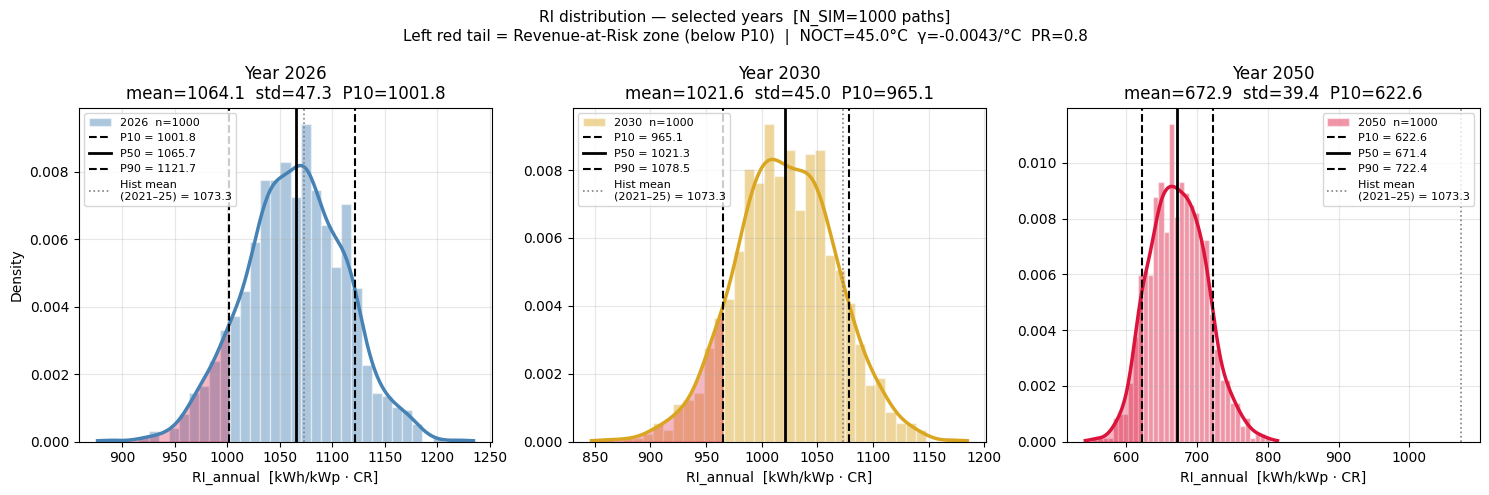

In [15]:
# ── RI distribution for selected years ───────────────────────────────────────
years_plot = [2026, 2030, 2050]
colors_yr  = {2026: "steelblue", 2030: "goldenrod", 2050: "crimson"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, yr in zip(axes, years_plot):
    ri_yr  = df_annual[df_annual["year"] == yr]["RI_annual"].values
    color  = colors_yr[yr]

    # histogram
    ax.hist(ri_yr, bins=35, density=True,
            color=color, alpha=0.45, edgecolor="white",
            label=f"{yr}  n={len(ri_yr)}")

    # KDE
    kde   = gaussian_kde(ri_yr)
    x_kde = np.linspace(ri_yr.min() - 10, ri_yr.max() + 10, 300)
    ax.plot(x_kde, kde(x_kde), color=color, lw=2.5)

    # percentile markers
    for pct, ls, lw in [(10, "--", 1.5), (50, "-", 2.0), (90, "--", 1.5)]:
        val = np.percentile(ri_yr, pct)
        ax.axvline(val, color="black", lw=lw, ls=ls,
                   label=f"P{pct} = {val:.1f}")

    # historical reference — mean of last 5 years
    hist_ref = df_hist_annual.tail(5)["RI_annual"].mean()
    ax.axvline(hist_ref, color="grey", lw=1.2, ls=":",
               label=f"Hist mean\n(2021–25) = {hist_ref:.1f}")

    # annotations
    ax.set_xlabel("RI_annual  [kWh/kWp · CR]")
    ax.set_ylabel("Density" if yr == 2026 else "")
    ax.set_title(
        f"Year {yr}\n"
        f"mean={ri_yr.mean():.1f}  "
        f"std={ri_yr.std():.1f}  "
        f"P10={np.percentile(ri_yr,10):.1f}"
    )
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # shade left tail (P10)
    x_tail = x_kde[x_kde <= np.percentile(ri_yr, 10)]
    ax.fill_between(x_tail, kde(x_tail),
                    alpha=0.30, color="crimson",
                    label="_RaR zone")

plt.suptitle(
    f"RI distribution — selected years  [N_SIM={N_SIM} paths]\n"
    f"Left red tail = Revenue-at-Risk zone (below P10)  |  "
    f"NOCT={NOCT}°C  γ={GAMMA}/°C  PR={PR}",
    fontsize=11
)
plt.tight_layout()
plt.show()

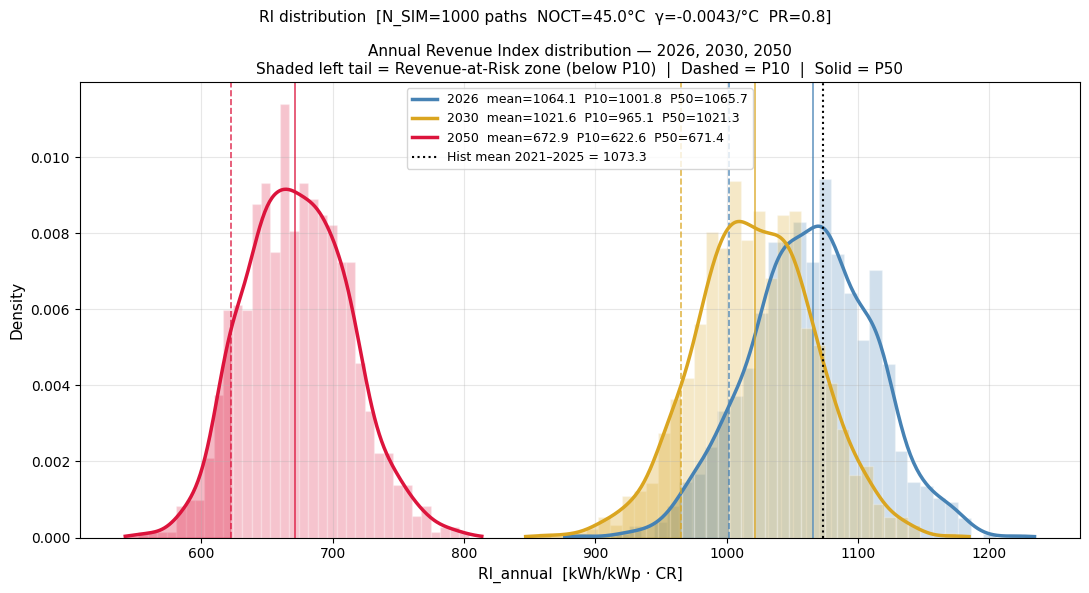

In [16]:
# ── RI distribution — all selected years on the same plot ────────────────────
years_plot = [2026, 2030, 2050]
colors_yr  = {2026: "steelblue", 2030: "goldenrod", 2050: "crimson"}

fig, ax = plt.subplots(figsize=(11, 6))

for yr in years_plot:
    ri_yr  = df_annual[df_annual["year"] == yr]["RI_annual"].values
    color  = colors_yr[yr]

    # histogram
    ax.hist(ri_yr, bins=35, density=True,
            color=color, alpha=0.25, edgecolor="white")

    # KDE
    kde   = gaussian_kde(ri_yr)
    x_kde = np.linspace(ri_yr.min() - 10, ri_yr.max() + 10, 300)
    ax.plot(x_kde, kde(x_kde), color=color, lw=2.5,
            label=f"{yr}  mean={ri_yr.mean():.1f}  "
                  f"P10={np.percentile(ri_yr,10):.1f}  "
                  f"P50={np.percentile(ri_yr,50):.1f}")

    # P10 and P50 markers
    for pct, ls in [(10, "--"), (50, "-")]:
        val = np.percentile(ri_yr, pct)
        ax.axvline(val, color=color, lw=1.2, ls=ls, alpha=0.8)

    # shade P10 left tail
    x_tail = x_kde[x_kde <= np.percentile(ri_yr, 10)]
    ax.fill_between(x_tail, kde(x_tail),
                    alpha=0.30, color=color)

# historical reference line — mean of last 5 years
hist_ref = df_hist_annual.tail(5)["RI_annual"].mean()
ax.axvline(hist_ref, color="black", lw=1.5, ls=":",
           label=f"Hist mean 2021–2025 = {hist_ref:.1f}")

ax.set_xlabel("RI_annual  [kWh/kWp · CR]", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    "Annual Revenue Index distribution — 2026, 2030, 2050\n"
    "Shaded left tail = Revenue-at-Risk zone (below P10)  |  "
    "Dashed = P10  |  Solid = P50",
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle(
    f"RI distribution  [N_SIM={N_SIM} paths  "
    f"NOCT={NOCT}°C  γ={GAMMA}/°C  PR={PR}]",
    fontsize=11
)
plt.tight_layout()
plt.show()

── Normality tests: RI_annual ───────────────────────────────────
  Year        n       mean       std     skew     kurt
  ------  -----  ---------  --------  -------  -------
  2026     1000    1064.12     47.26   -0.075    0.032
  2030     1000    1021.56     45.04   -0.047    0.086
  2050     1000     672.93     39.39    0.179   -0.135

  Year     Shapiro-W         p     DAgostino         p   Jarque-Bera         p   KS-Normal         p   Normal?
  ------  ----------  --------  ------------  --------  ------------  --------  ----------  --------  --------


  2026        0.9988    0.7396        1.0520    0.5910        0.9816    0.6121      0.0178    0.9052  ✓ Normal
  2030        0.9992    0.9656        0.8059    0.6683        0.6832    0.7106      0.0158    0.9612  ✓ Normal
  2050        0.9966    0.0279        6.0235    0.0492        6.0997    0.0474      0.0284    0.3877  ✗ Non-normal


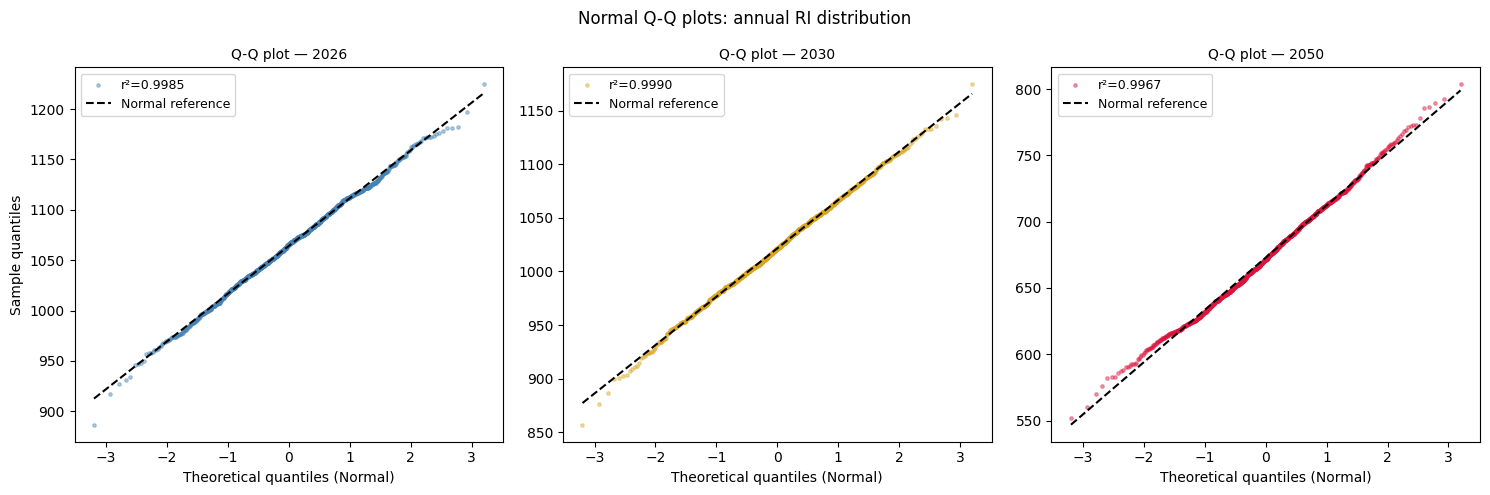

In [17]:
from scipy.stats import shapiro, normaltest, jarque_bera, norm, kstest

TARGET_YEARS = [2026, 2030, 2050]

print("── Normality tests: RI_annual ───────────────────────────────────")
print(f"  {'Year':<6}  {'n':>5}  {'mean':>9}  {'std':>8}  {'skew':>7}  {'kurt':>7}")
print(f"  {'-'*6}  {'-'*5}  {'-'*9}  {'-'*8}  {'-'*7}  {'-'*7}")
for yr in TARGET_YEARS:
    x = df_annual.loc[df_annual["year"] == yr, "RI_annual"].values
    from scipy.stats import skew, kurtosis
    print(f"  {yr:<6}  {len(x):>5}  {x.mean():>9.2f}  {x.std():>8.2f}  "
          f"{skew(x):>7.3f}  {kurtosis(x):>7.3f}")

print()
print(f"  {'Year':<6}  {'Shapiro-W':>10}  {'p':>8}  "
      f"{'DAgostino':>12}  {'p':>8}  "
      f"{'Jarque-Bera':>12}  {'p':>8}  "
      f"{'KS-Normal':>10}  {'p':>8}  {'Normal?':>8}")
print(f"  {'-'*6}  {'-'*10}  {'-'*8}  {'-'*12}  {'-'*8}  "
      f"{'-'*12}  {'-'*8}  {'-'*10}  {'-'*8}  {'-'*8}")

for yr in TARGET_YEARS:
    x  = df_annual.loc[df_annual["year"] == yr, "RI_annual"].values
    mu, sigma = x.mean(), x.std(ddof=1)

    sw_stat,  sw_p  = shapiro(x)
    da_stat,  da_p  = normaltest(x)
    jb_stat,  jb_p  = jarque_bera(x)
    ks_stat,  ks_p  = kstest(x, lambda v: norm.cdf(v, loc=mu, scale=sigma))

    reject = sum([sw_p < 0.05, da_p < 0.05, jb_p < 0.05, ks_p < 0.05])
    conclusion = "✓ Normal" if reject == 0 else ("~ Borderline" if reject <= 2 else "✗ Non-normal")

    print(f"  {yr:<6}  {sw_stat:>10.4f}  {sw_p:>8.4f}  "
          f"{da_stat:>12.4f}  {da_p:>8.4f}  "
          f"{jb_stat:>12.4f}  {jb_p:>8.4f}  "
          f"{ks_stat:>10.4f}  {ks_p:>8.4f}  {conclusion:>8}")

# ── QQ plots ──────────────────────────────────────────────────────────────────
from scipy.stats import probplot

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_yr = {2026: "steelblue", 2030: "goldenrod", 2050: "crimson"}

for ax, yr in zip(axes, TARGET_YEARS):
    x     = df_annual.loc[df_annual["year"] == yr, "RI_annual"].values
    color = colors_yr[yr]

    (osm, osr), (slope, intercept, r) = probplot(x, dist="norm")
    ax.scatter(osm, osr, s=6, alpha=0.4, color=color, label=f"r²={r**2:.4f}")
    ax.plot(osm, slope * np.array(osm) + intercept,
            color="black", lw=1.5, ls="--", label="Normal reference")

    ax.set_title(f"Q-Q plot — {yr}", fontsize=10)
    ax.set_xlabel("Theoretical quantiles (Normal)")
    ax.set_ylabel("Sample quantiles" if yr == 2026 else "")
    ax.legend(fontsize=9)

plt.suptitle("Normal Q-Q plots: annual RI distribution", fontsize=12)
plt.tight_layout()
plt.show()